# Сквозной анализ цепи поставок

Когда товара нет на полке магазина, важно понять, **на каком этапе цепочки** возникла проблема - от этого
зависит, кто и что должен исправить. Ноутбук восстанавливает движение товара по дням на всех этапах и для
каждого дня дефицита в магазине находит причину.

```
                 ПОСТАВЩИК
                     │  закуп раз в неделю (понедельник), доставка 2 дня
        ┌────────────┼────────────┐
     Склад        Склад        Склад
        │            │            │  пополнение магазинов каждый день, доставка 1 день
    магазины     магазины     магазины
        │            │            │
               покупатели
```

**Итоги разбора.** Каждый день, когда магазин стоял без товара, получает один итог:

| Этап | Итог | Что произошло |
|---|---|---|
| Распределение | ошибка распределения | на складе товар был, а магазин остался пустым |
| Распределение | перекос распределения | склад пуст, а в других магазинах этого склада товар лежит с избытком |
| Закуп | ошибка закупа | склад пуст, поставщик привёз всё, что заказали (или заказа не было), - заказали недостаточно |
| Закуп | перекос закупа | поставщик привёз меньше заказа, а в других регионах товар лежит с избытком |
| Поставщик | дефицит у поставщика | поставщик привёз меньше заказа и излишков нигде нет - товара не хватило на всех, это не ошибка |

**Два вида дефицита** разбираются по одной схеме и показываются отдельно:
- *весь день без товара* - утром товара в магазине не было, и за день он не пришёл;
- *закончился за день* - утром товар был, а к вечеру остаток ноль: часть покупателей пришла, когда товара уже
  не было.

Статус модели (новинка, основной ассортимент, выводимая) на разбор не влияет: если товар продаётся, на него
есть спрос и его нужно закупать.

**Про данные.** Расчёт идёт на синтетических данных из общей базы [`../synthetic_data`](../synthetic_data):
симуляция сети магазинов электроники (смартфоны Apple, выход iPhone 17 в конце сентября 2025) с поставщиком,
тремя складами и магазинами. Разбор использует только то, что есть в учётной системе: заказы поставщику,
журнал движений и текущий остаток. В симуляцию специально заложены проблемы на каждом этапе - в конце
ноутбука проверяется, что разбор их находит.

## Импорт библиотек и параметры

In [1]:
# Библиотеки, настройки графиков и параметры разбора. Параметры вынесены сюда, чтобы их было легко менять.
import os
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import poisson
from IPython.display import Image

pd.options.display.max_columns = 50
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=FutureWarning)

# путь к базе с синтетикой; можно переопределить переменной окружения
DB_PATH = os.environ.get('SYNTH_DB', '../synthetic_data/synthetic_projects.duckdb')

# излишек в магазине - запас больше чем на неделю его продаж (при ежедневном пополнении больше не нужно)
STORE_EXCESS_DAYS = 7
# излишек в регионе - запас склада и магазинов больше чем на 2 недели продаж региона (неделя склад + неделя магазины)
REGION_EXCESS_DAYS = 14
# окно для оценки ожидаемых продаж в дни дефицита: ±LOST_WINDOW дней
LOST_WINDOW = 7

con = duckdb.connect(DB_PATH)
q = lambda sql: con.execute(sql).df()   # SQL-запрос к базе -> датафрейм

## Загрузка данных

In [2]:
# Загружаем из учётной системы всё, что нужно для разбора: справочники, журнал движений,
# заказы поставщику и текущий остаток. Ссылки на филиалы сразу заменяем их названиями.

# справочник товаров с ценой продажи; префикс «Смартфон Apple» убираем, чтобы названия были короче
products = q('''
    SELECT p.ТоварСсылка AS Номенклатура, replace(p.Товар, 'Смартфон Apple ', '') AS Товар, p.Модель,
           p.Ассортиментный_Статус AS Статус, c.ЦенаПродажи AS Цена
    FROM supply.products p JOIN supply.prices c ON c.Номенклатура = p.ТоварСсылка''')
# филиалы: склады и магазины, у магазина - склад, который его пополняет
branches = q('SELECT Филиал, Вид_филиала, ПриписанК_Складу AS Склад FROM supply.branches')
# журнал движений: поступления от поставщика и со склада, отгрузки в магазины, продажи
journal = q('''
    SELECT j.Дата, b.Филиал, j.Номенклатура, j.Операция, j.ВидДвижения, j.Количество
    FROM supply.journal j JOIN supply.branches b ON b.ФилиалСсылка = j.Филиал''')
# еженедельные заказы поставщику: сколько заказали и сколько поставщик подтвердил
orders = q('''
    SELECT o.ДатаЗаказа, o.ДатаПоступления, b.Филиал AS Склад, o.Номенклатура, o.Заказано, o.Подтверждено
    FROM supply.supplier_orders o JOIN supply.branches b ON b.ФилиалСсылка = o.Склад''')
# текущий остаток - на последний день периода
stock_now = q('''
    SELECT s.ДатаОстатка, b.Филиал, s.Номенклатура, s.Остаток, s.Транзит
    FROM supply.stock_now s JOIN supply.branches b ON b.ФилиалСсылка = s.Филиал''')

# справочные списки и соответствия, которые понадобятся дальше
warehouses = branches.loc[branches.Вид_филиала == 'Склад', 'Филиал'].tolist()
stores = branches.loc[branches.Вид_филиала == 'Магазин', 'Филиал'].tolist()
store_wh = branches.set_index('Филиал')['Склад']              # магазин -> его склад
price = products.set_index('Номенклатура')['Цена']
sku_name = products.set_index('Номенклатура')['Товар']
dates = pd.date_range(journal.Дата.min(), stock_now.ДатаОстатка.max())

print(f'период {dates[0]:%d.%m.%Y} - {dates[-1]:%d.%m.%Y}, складов {len(warehouses)}, магазинов {len(stores)}, '
      f'товаров {len(products)}')
print(f'заказов поставщику {len(orders):,}, строк журнала движений {len(journal):,}')

период 01.08.2025 - 31.10.2025, складов 3, магазинов 30, товаров 60
заказов поставщику 1,736, строк журнала движений 102,308


## 1. Восстановление остатков по дням

Учётная система хранит текущий остаток и журнал движений. Остаток на каждый прошлый день получается
«откатом» назад: из остатка на конец периода вычитаются все движения после нужного дня. Так считается
и для складов, и для магазинов.

In [3]:
# Восстанавливаем остаток каждого склада и магазина по каждому товару на начало и конец каждого дня.
# Все расчёты дальше идут на таблицах «день × (филиал, товар)».
pairs = pd.MultiIndex.from_product([warehouses + stores, products.Номенклатура], names=['Филиал', 'Номенклатура'])


def cube(frame: pd.DataFrame, value: str = 'Количество') -> pd.DataFrame:
    """Таблица «день × (филиал, товар)» с нулями там, где движений не было."""
    t = frame.pivot_table(index='Дата', columns=['Филиал', 'Номенклатура'], values=value, aggfunc='sum')
    return t.reindex(index=dates, columns=pairs).fillna(0)


# чистое движение за день: приход со знаком плюс, расход со знаком минус
journal['Чистое'] = np.where(journal.ВидДвижения == 0, 1, -1) * journal.Количество
net = cube(journal, 'Чистое')
end_last = stock_now.set_index(['Филиал', 'Номенклатура'])['Остаток'].reindex(pairs).fillna(0)

# остаток на конец дня = остаток на конец периода минус движения всех следующих дней
# (сумма «с конца» по дням, сдвинутая на день: для последнего дня вычитать нечего)
after = net[::-1].cumsum()[::-1].shift(-1).fillna(0)
stock_end = end_last - after
stock_start = stock_end - net                # на начало дня = на конец дня минус движения этого дня

# отдельные виды движений понадобятся для разбора
arrivals = cube(journal[journal.Операция.str.startswith('Поступление')])   # приходы (утром)
sales = cube(journal[journal.Операция == 'Продажа'])
shipments = cube(journal[journal.Операция == 'Отгрузка в магазин'])

**Проверка.** В симуляции есть истинный остаток на начало каждого дня - сверяем с восстановленным.
В реальных данных этой таблицы нет, это проверка метода.

In [4]:
# Сверяем восстановленные остатки с истинными из симуляции (таблица-истина используется только для проверки).
truth = q('''
    SELECT t.Дата, b.Филиал, t.Номенклатура, t.ОстатокНаНачалоДня, t.СпросИстинный
    FROM supply.truth_daily t JOIN supply.branches b ON b.ФилиалСсылка = t.Филиал''')
true_start = cube(truth, 'ОстатокНаНачалоДня')
diff = (stock_start - true_start).abs()
print(f'совпадает строк: {(diff == 0).to_numpy().mean():.1%} из {diff.size:,}, '
      f'максимальное расхождение {diff.to_numpy().max():.0f} шт.')

совпадает строк: 100.0% из 182,160, максимальное расхождение 0 шт.


## 2. Дни дефицита и сквозная картина по товару

Сначала находим дни дефицита в магазинах, затем готовим график, который показывает один товар на всех
этапах сразу: сколько закупщик заказал и сколько подтвердил поставщик, как менялся остаток на складах и
сколько магазинов каждого склада были в дефиците.

In [5]:
# Находим дни дефицита двух видов и считаем ожидаемые продажи - они нужны и для разбора, и для оценки потерь.
S = stock_start[stores]                      # остаток магазина на начало дня
avail = S + arrivals[stores]                 # товар, доступный магазину в течение дня (с утренним приходом)
end_s = stock_end[stores]                    # остаток на конец дня

# товар считается «в продаже» с первого дня, когда он продался где-либо в сети (новинки - с даты старта)
first_sale = sales[stores].T.groupby(level='Номенклатура').sum().T.gt(0).idxmax()
active = pd.DataFrame(np.array([dates >= first_sale[p] for _, p in S.columns]).T, index=dates, columns=S.columns)

empty_all_day = (avail == 0) & active                  # товара не было весь день
sold_out = (avail > 0) & (end_s == 0) & active         # утром был, к вечеру закончился
deficit = empty_all_day | sold_out

# ожидаемые продажи в день: средние продажи в дни, когда товар был в магазине, в окне ±LOST_WINDOW дней;
# если в окне таких дней мало - средние за весь период
on_shelf = sales[stores].where(avail > 0)
expected = (on_shelf.rolling(2 * LOST_WINDOW + 1, center=True, min_periods=3).mean()
            .fillna(on_shelf.mean()).fillna(0))


def chain_plot(sku: str):
    """Сквозной график одного товара: закуп у поставщика, остатки складов, магазины в дефиците."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, gridspec_kw={'height_ratios': [1, 1.2, 1]})

    # верх: заказано и подтверждено поставщиком по неделям - два столбика рядом
    o = orders[orders.Номенклатура == sku].groupby('ДатаЗаказа')[['Заказано', 'Подтверждено']].sum()
    axes[0].bar(o.index - pd.Timedelta(hours=20), o.Заказано, width=1.6, color='#9ecae1', label='заказано')
    axes[0].bar(o.index + pd.Timedelta(hours=20), o.Подтверждено, width=1.6, color='#3182bd',
                label='подтвердил поставщик')
    axes[0].set(title='Закуп у поставщика (все склады), шт.'); axes[0].legend(loc='upper left')

    # середина и низ: по каждому складу - его остаток и число его магазинов в дефиците
    for w in warehouses:
        axes[1].plot(dates, stock_start[(w, sku)], label=w, lw=1.8)
        kids = [s for s in stores if store_wh[s] == w]
        axes[2].plot(dates, deficit.loc[:, [(s, sku) for s in kids]].sum(axis=1), lw=1.8, label=w)
    axes[1].set(title='Остаток на складе на начало дня, шт.'); axes[1].legend(loc='upper left')
    axes[2].set(title='Магазинов в дефиците (весь день или к вечеру)'); axes[2].legend(loc='upper left')
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    fig.suptitle(sku_name[sku], fontsize=13); fig.tight_layout(); plt.show()

## 3. Причина каждого дня дефицита

Для каждого дня дефицита в магазине идём по цепочке вверх - от магазина к складу, от склада к
поставщику - и останавливаемся на первой найденной причине. Схема разбора:

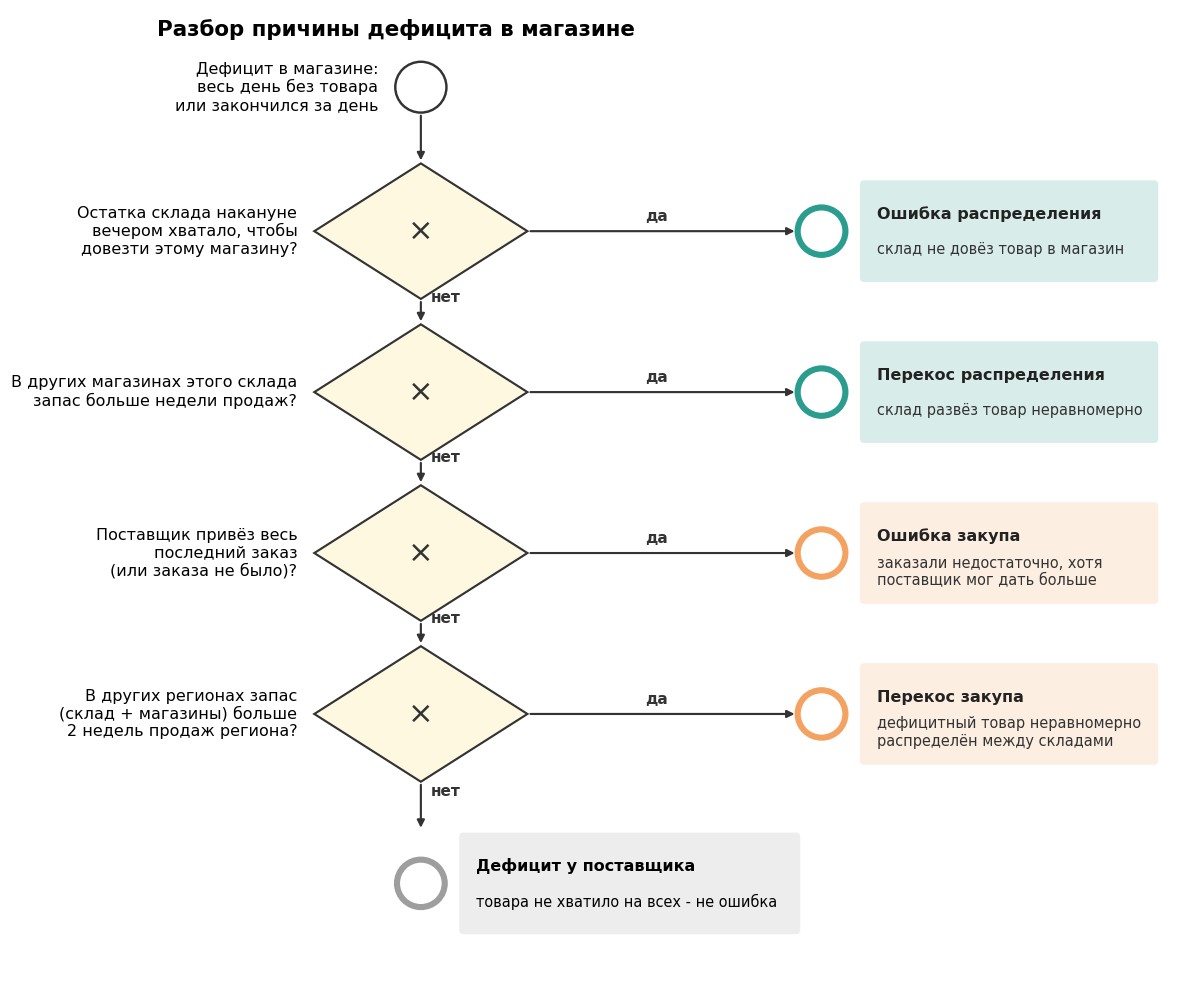

In [6]:
# Схема разбора (рисуется скриптом схема_разбора.py в этой же папке).
Image('схема_разбора.png', width=760)

Детали проверок:

- **Остаток склада** берётся на начало дня - это то, что осталось на складе вечером накануне, когда
  собирались отгрузки в магазины (доставка в магазин - 1 день).
- **Хватало ли склада этому магазину.** Если в дефиците сразу несколько магазинов склада, остатка может хватить
  не всем. Каждому магазину нужно хотя бы на день продаж (не меньше 1 шт.); магазины с большими продажами
  обслуживаются первыми. Если к очереди этого магазина на складе ещё что-то оставалось - это ошибка
  распределения, иначе разбор идёт дальше.
- **Неделя продаж магазина** - средние продажи этого товара в этом магазине в дни, когда товар был, умноженные
  на 7 и округлённые вверх до целой штуки: при продажах 0,7 шт. в неделю одна штука на полке - норма, две - излишек.
- **Последний заказ** - последний заказ поставщику по этому складу и товару, который пришёл на склад до дня дефицита.
- **Регион** - склад и все его магазины. Две недели продаж региона - сумма недельных продаж его магазинов,
  умноженная на 2 и округлённая вверх до штуки.

In [7]:
# Разбор: для каждого дня дефицита по очереди выполняем проверки со схемы и присваиваем итог.

# одна строка на каждый «магазин × товар × день» с дефицитом
dd = deficit.stack([0, 1], future_stack=True)
dd = dd[dd].index.to_frame(index=False)
dd.columns = ['Дата', 'Магазин', 'Номенклатура']
dd['Склад'] = dd.Магазин.map(store_wh)


def lookup(frame: pd.DataFrame, cols: list) -> np.ndarray:
    """Значения таблицы «день × (филиал, товар)» для строк dd по колонкам cols."""
    return frame.stack([0, 1], future_stack=True).reindex(pd.MultiIndex.from_frame(dd[cols])).to_numpy()


def by_warehouse(frame: pd.DataFrame) -> pd.DataFrame:
    """Сумма по магазинам каждого склада: «день × (склад, товар)»."""
    t = frame.T.groupby([store_wh.reindex(frame.columns.get_level_values(0)).to_numpy(),
                         frame.columns.get_level_values(1)]).sum().T
    t.columns.names = ['Склад', 'Номенклатура']
    return t


SMN = ['Дата', 'Магазин', 'Номенклатура']   # ключ строки дефицита
dd['Вид'] = np.where(lookup(empty_all_day, SMN), 'весь день без товара', 'закончился за день')
dd['Ожидаемые_продажи'] = lookup(expected, SMN)

# --- проверка 1: хватало ли остатка склада этому магазину ---
W = stock_start[warehouses]
dd['Остаток_склада'] = lookup(W, ['Дата', 'Склад', 'Номенклатура'])
# потребность магазина - хотя бы на день продаж, за вычетом того, что было утром, но не меньше 1 шт.
dd['Потребность'] = np.maximum(1, np.ceil(dd.Ожидаемые_продажи) - lookup(avail, SMN))
# очередь внутри «склад × товар × день»: сначала магазины с большими продажами
dd = dd.sort_values(['Дата', 'Склад', 'Номенклатура', 'Ожидаемые_продажи'], ascending=[True, True, True, False])
# сколько склад должен был отдать магазинам, стоящим в очереди раньше этого
dd['Нужно_до_магазина'] = dd.groupby(['Дата', 'Склад', 'Номенклатура']).Потребность.cumsum() - dd.Потребность
dd['Склад_мог_довезти'] = dd.Нужно_до_магазина < dd.Остаток_склада

# --- проверка 2: излишки в других магазинах этого склада - запас больше недели их продаж ---
rate = on_shelf.mean().fillna(0)                                 # продаж в день, когда товар был
excess = S.gt(np.ceil(rate * STORE_EXCESS_DAYS), axis=1)          # больше недели продаж, округлённой до штуки
# число магазинов склада с излишком минус сам магазин (у него дефицит, но на всякий случай)
dd['Излишки_в_магазинах'] = (lookup(by_warehouse(excess.astype(int)), ['Дата', 'Склад', 'Номенклатура'])
                             - lookup(excess.astype(int), SMN)) > 0

# --- проверка 3: последний заказ поставщику, пришедший на склад до дня дефицита ---
# merge_asof берёт для каждой строки ближайший заказ с датой поступления строго раньше дня дефицита
dd = pd.merge_asof(dd.sort_values('Дата', kind='stable'), orders.sort_values('ДатаПоступления'),
                   left_on='Дата', right_on='ДатаПоступления', by=['Склад', 'Номенклатура'],
                   allow_exact_matches=False)
# «привёз всё» - и когда заказа не было вовсе: товар не заказали, значит, проблема не у поставщика
dd['Поставщик_привёз_всё'] = dd.ДатаЗаказа.isna() | (dd.Подтверждено >= dd.Заказано)

# --- проверка 4: излишки в других регионах - запас склада и магазинов больше 2 недель продаж региона ---
region_stock = W + by_warehouse(S).reindex(columns=W.columns, fill_value=0)
region_rate = rate.groupby([store_wh.reindex(rate.index.get_level_values(0)).to_numpy(),
                            rate.index.get_level_values(1)]).sum().reindex(W.columns, fill_value=0)
region_excess = region_stock.gt(np.ceil(region_rate * REGION_EXCESS_DAYS), axis=1).astype(int)
n_excess = region_excess.T.groupby(level='Номенклатура').sum().T              # регионов с излишком по товару
# излишек хотя бы в одном другом регионе (свой регион из счёта исключаем)
dd['Излишки_в_регионах'] = (n_excess.stack().reindex(pd.MultiIndex.from_frame(dd[['Дата', 'Номенклатура']])).to_numpy()
                            - lookup(region_excess, ['Дата', 'Склад', 'Номенклатура'])) > 0

# итог - первое сработавшее условие по порядку схемы; если ни одно - дефицит у поставщика
dd['Итог'] = np.select(
    [dd.Склад_мог_довезти, dd.Излишки_в_магазинах, dd.Поставщик_привёз_всё, dd.Излишки_в_регионах],
    ['ошибка распределения', 'перекос распределения', 'ошибка закупа', 'перекос закупа'],
    default='дефицит у поставщика')
STAGE = {'ошибка распределения': 'Распределение', 'перекос распределения': 'Распределение',
         'ошибка закупа': 'Закуп', 'перекос закупа': 'Закуп', 'дефицит у поставщика': 'Поставщик'}
dd['Этап'] = dd.Итог.map(STAGE)

**Сколько продаж потеряно.** Ожидаемые продажи в день - средние продажи этого товара в этом магазине в дни,
когда товар был, в окне ±7 дней (так учитывается ажиотаж на старте новинки).

- **Весь день без товара** - потеряны все ожидаемые продажи дня.
- **Закончился за день** - всё, что было, продано, но сколько покупателей пришло уже после этого, учёт не видит.
  Покупатели приходят случайно (распределение Пуассона), поэтому по среднему спросу и остатку на утро можно
  посчитать, сколько их в среднем пришло после того, как товар кончился. Например, при среднем спросе 2 шт.
  в день и 1 шт. на полке утром - в среднем ещё 1,3 покупателя.

Для проверки рядом - истинный неудовлетворённый спрос из симуляции.

In [8]:
# Оцениваем упущенные продажи каждого дня дефицита, сверяем с истиной и сводим потери по итогам разбора.


def lost_after_sellout(lam: np.ndarray, stock: np.ndarray) -> np.ndarray:
    """Сколько покупателей в среднем пришло после того, как товар кончился: E[спрос - остаток | спрос >= остаток]."""
    k = np.arange(0, 200)[:, None]                                      # возможное число покупателей за день
    over = (np.maximum(k - stock, 0) * poisson.pmf(k, lam)).sum(axis=0)  # среднее «сверх остатка»
    return over / np.maximum(poisson.sf(stock - 1, lam), 1e-9)          # при условии, что товар кончился


sold = lookup(sales[stores], SMN)
morning = lookup(avail, SMN)
dd['Упущено_шт'] = np.where(dd.Вид == 'весь день без товара', dd.Ожидаемые_продажи,
                            lost_after_sellout(dd.Ожидаемые_продажи.clip(lower=1e-6).to_numpy(), morning))
dd['Упущено_руб'] = dd.Упущено_шт * dd.Номенклатура.map(price)
# истина для проверки: спрос из симуляции минус фактические продажи
true_demand = cube(truth, 'СпросИстинный')[stores]
dd['Упущено_истинно_руб'] = np.maximum(0, lookup(true_demand, SMN) - sold) * dd.Номенклатура.map(price)

# общие цифры: сколько дней дефицита каждого вида и сколько потеряно
sales_rub = (sales[stores] * price.reindex(sales[stores].columns.get_level_values(1)).to_numpy()).to_numpy().sum()
n_active = int(active.to_numpy().sum())
for kind, n in dd.Вид.value_counts().items():
    print(f'{kind}: {n:,} «магазино-дней», {n / n_active:.1%} от дней в продаже')
print(f'упущенные продажи: {dd.Упущено_руб.sum() / 1e6:.1f} млн ₽ ({dd.Упущено_руб.sum() / sales_rub:.1%} от продаж), '
      f'истинные по симуляции {dd.Упущено_истинно_руб.sum() / 1e6:.1f} млн ₽')

# потери по итогам разбора и видам дефицита
by_cause = dd.pivot_table(index=['Этап', 'Итог'], columns='Вид', values='Упущено_руб', aggfunc='sum', fill_value=0) / 1e6
by_cause['всего'] = by_cause.sum(axis=1)
by_cause['доля'] = by_cause.всего / by_cause.всего.sum()
by_cause = by_cause.sort_values('всего', ascending=False)
by_cause.style.format('{:.1f}').format('{:.0%}', subset='доля').set_caption('Упущенные продажи, млн ₽')

закончился за день: 6,957 «магазино-дней», 5.7% от дней в продаже
весь день без товара: 3,685 «магазино-дней», 3.0% от дней в продаже
упущенные продажи: 308.3 млн ₽ (5.4% от продаж), истинные по симуляции 258.2 млн ₽


,Вид,весь день без товара,закончился за день,всего,доля
Этап,Итог,,,,
Распределение,ошибка распределения,13.4,113.9,127.4,41%
Закуп,ошибка закупа,61.3,13.9,75.2,24%
Поставщик,дефицит у поставщика,61.9,9.5,71.4,23%
Распределение,перекос распределения,16.0,3.6,19.6,6%
Закуп,перекос закупа,12.3,2.5,14.7,5%


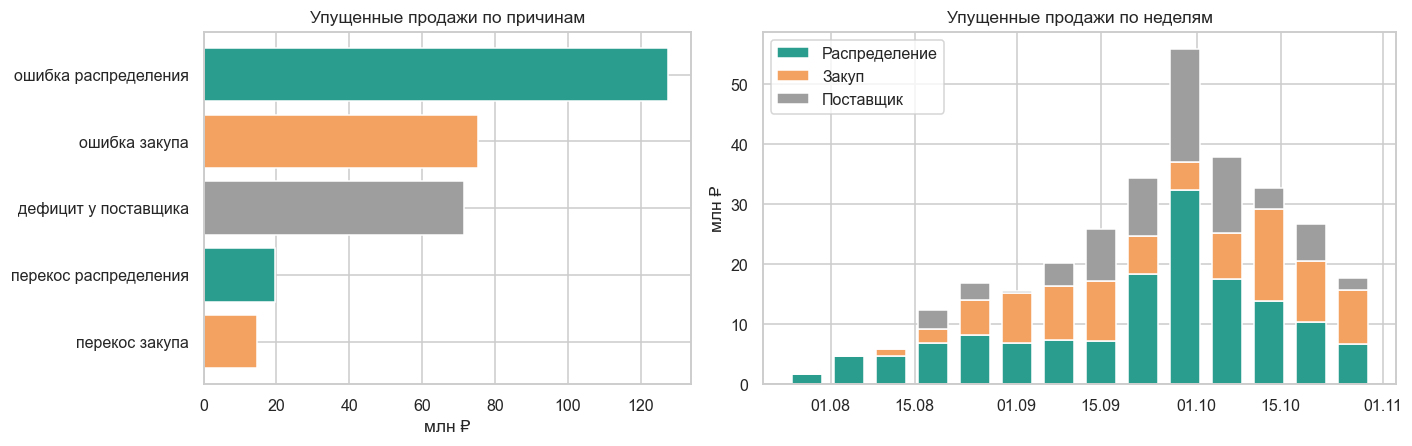

In [9]:
# Графики: потери по итогам разбора и по неделям в разрезе этапов цепочки.
colors = {'Распределение': '#2a9d8f', 'Закуп': '#f4a261', 'Поставщик': '#9e9e9e'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1, 1.3]})

# слева: итоги разбора, цвет - этап
bc = by_cause.reset_index().sort_values('всего')
axes[0].barh(bc.Итог, bc.всего, color=bc.Этап.map(colors))
axes[0].set(title='Упущенные продажи по причинам', xlabel='млн ₽')

# справа: по неделям (неделя - с понедельника), столбики сложены по этапам
week = dd.assign(Неделя=dd.Дата - pd.to_timedelta(dd.Дата.dt.dayofweek, unit='D'))
wk = week.pivot_table(index='Неделя', columns='Этап', values='Упущено_руб', aggfunc='sum', fill_value=0) / 1e6
wk = wk.reindex(pd.date_range(dates[0] - pd.Timedelta(days=dates[0].dayofweek), dates[-1], freq='7D'), fill_value=0)
bottom = np.zeros(len(wk))
for st in [c for c in colors if c in wk]:
    axes[1].bar(wk.index, wk[st], bottom=bottom, width=5, color=colors[st], label=st)
    bottom += wk[st].to_numpy()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
axes[1].set(title='Упущенные продажи по неделям', ylabel='млн ₽'); axes[1].legend(loc='upper left')
fig.tight_layout(); plt.show()

In [10]:
# Потери по складам (регионам) в разрезе этапов цепочки, млн ₽.
by_wh = dd.pivot_table(index='Склад', columns='Этап', values='Упущено_руб', aggfunc='sum', fill_value=0) / 1e6
by_wh['всего'] = by_wh.sum(axis=1)
by_wh.sort_values('всего', ascending=False).style.format('{:.1f}')

Этап,Закуп,Поставщик,Распределение,всего
Склад,,,,
Склад Москва,32.4,40.8,69.4,142.6
Склад Екатеринбург,27.9,16.1,51.5,95.5
Склад Новосибирск,29.6,14.5,26.0,70.2


Сквозная картина по товару, на котором встречается больше всего разных причин:

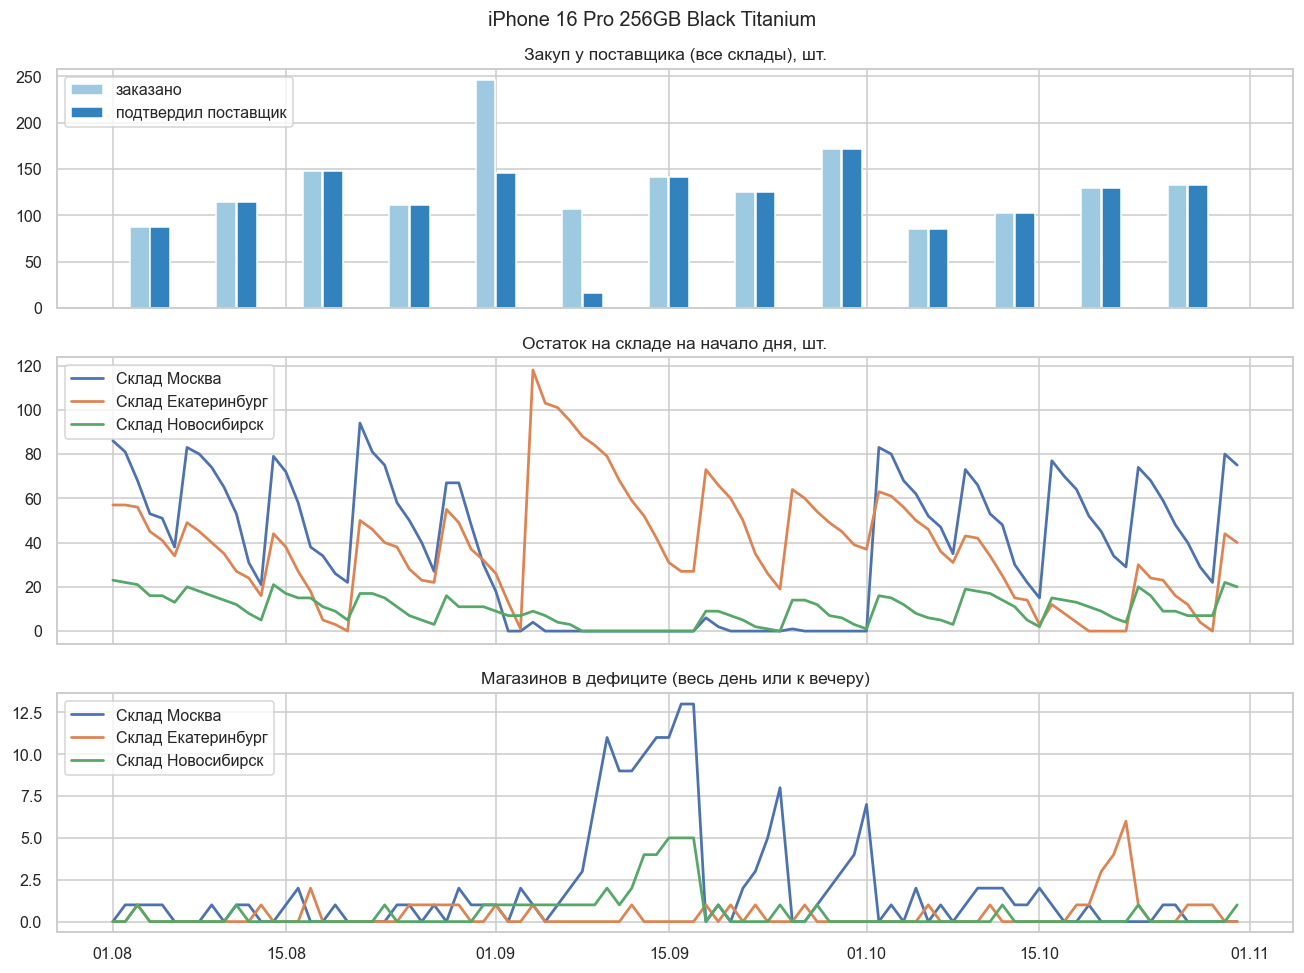

дней
Склад              Этап          Итог                       
Склад Екатеринбург Закуп         ошибка закупа            15
                   Распределение ошибка распределения     22
Склад Москва       Закуп         ошибка закупа            18
                                 перекос закупа           33
                   Поставщик     дефицит у поставщика     67
                   Распределение ошибка распределения     40
                                 перекос распределения    19
Склад Новосибирск  Закуп         ошибка закупа             1
                                 перекос закупа            5
                   Поставщик     дефицит у поставщика     25
                   Распределение ошибка распределения     16

In [11]:
# Выбираем товар с наибольшим числом разных итогов (при равенстве - с большими потерями) и рисуем его цепочку.
mix = dd.groupby('Номенклатура').agg(n=('Итог', 'nunique'), lost=('Упущено_руб', 'sum'))
example = mix.sort_values(['n', 'lost'], ascending=False).index[0]
chain_plot(example)
dd[dd.Номенклатура == example].groupby(['Склад', 'Этап', 'Итог']).size().rename('дней').to_frame()

## 4. Проверка на заложенных проблемах

В симуляцию заранее заложены проблемы: дефицит у поставщика и квота на новинку, недозаказы и перезаказы
закупщика, перекос закупа (в дефицит дефицитный товар отдали одному складу), пропуски пополнения магазинов и
перезатарка отдельных магазинов.
Для каждого дня дефицита определяем, какая заложенная проблема за ним стоит, и сравниваем с тем, что назвал
разбор. Проблемы поставщика и закупа считаются причиной, только если в этот день склад не мог довезти товар. Дни, за которыми заложенной проблемы нет, - это следствие самих правил работы цепочки: размера
запасов и правила прогноза закупа, о них - в следующих разделах.

In [12]:
# Сравниваем итоги разбора с проблемами, заложенными в симуляцию (таблица-истина, только для проверки).
ev = q('''
    SELECT e.Этап, e.Проблема, b.Филиал, e.Номенклатура, e.ДатаС, e.ДатаПо
    FROM supply.truth_events e LEFT JOIN supply.branches b ON b.ФилиалСсылка = e.Филиал''')


def planted(r) -> str:
    """Какая заложенная проблема стоит за днём дефицита (по истине симуляции). Порядок - как в схеме разбора."""
    e = ev[ev.Номенклатура == r.Номенклатура]
    prev = r.Дата - pd.Timedelta(days=1)
    # магазину не делали заявку накануне или в предыдущие дни
    x = e[(e.Проблема == 'пропуск пополнения магазина') & (e.Филиал == r.Магазин)]
    if ((x.ДатаС <= prev) & (x.ДатаПо >= prev - pd.Timedelta(days=4))).any():
        return 'Распределение'
    # соседний магазин того же склада перезатарен, а склад пуст
    x = e[(e.Проблема == 'перезатарка магазина') & (e.Филиал.map(store_wh) == r.Склад) & (e.Филиал != r.Магазин)]
    if r.Остаток_склада == 0 and ((x.ДатаС <= r.Дата) & (x.ДатаПо >= r.Дата - pd.Timedelta(days=7))).any():
        return 'Распределение'
    # проблемы поставщика и закупа могут быть причиной, только если склад не мог довезти товар:
    # если товар на складе был, дефицит в магазине от них не зависит
    # дальше смотрим на заказ поставщику, который кормил склад в этот день
    if not r.Склад_мог_довезти and pd.notna(r.ДатаЗаказа):
        x = e[(e.Проблема == 'перекос закупа при дефиците') & (e.ДатаС == r.ДатаЗаказа) & (e.Филиал != r.Склад)]
        if len(x):
            return 'Закуп'
        x = e[e.Этап == 'Поставщик']
        if ((x.ДатаС <= r.ДатаЗаказа) & (x.ДатаПо >= r.ДатаЗаказа)).any():
            return 'Поставщик'
        x = e[(e.Этап == 'Закуп') & (e.Филиал == r.Склад) & (e.ДатаС == r.ДатаЗаказа)
              & e.Проблема.str.contains('недозаказ')]
        if len(x):
            return 'Закуп'
    return 'без заложенной проблемы'


dd['Заложено'] = dd.apply(planted, axis=1)
# таблица «заложено × назвал разбор» в деньгах; на диагонали - совпадения
check = pd.crosstab(dd.Заложено, dd.Этап, values=dd.Упущено_руб / 1e6, aggfunc='sum').fillna(0)
hit = sum(check.at[s, s] for s in check.index if s in check.columns) / check.drop('без заложенной проблемы', errors='ignore').to_numpy().sum()
print(f'из потерь, за которыми стоит заложенная проблема, разбор назвал верный этап для {hit:.0%}')
check.style.format('{:.1f}').set_caption('Упущенные продажи, млн ₽: строки - заложено, столбцы - назвал разбор')

из потерь, за которыми стоит заложенная проблема, разбор назвал верный этап для 84%


Этап,Закуп,Поставщик,Распределение
Заложено,,,
Закуп,42.5,0.5,3.3
Поставщик,6.8,65.6,2.9
Распределение,5.3,5.3,19.9
без заложенной проблемы,35.3,0.0,120.9


## 5. Фактические запасы: хватает ли их

Сколько дней продаж на самом деле покрывает запас магазинов и складов и как это связано с дефицитом. Запас
в днях - остаток, делённый на средние продажи в день (для склада - на продажи всех его магазинов). Пары
«товар - магазин» и «товар - склад» группируются по среднему запасу за период, и для каждой группы считается,
какую долю дней товар был в дефиците. Если дефицит резко падает с ростом запаса, запасы в нижних группах
малы; если в верхних группах дефицита почти нет, а запас растёт дальше, - там запасы избыточны.

In [13]:
# Средний запас каждой пары в днях продаж и доля дней дефицита; группировка пар по размеру запаса.
STORE_BINS, STORE_LABELS = [0, 3, 5, 7, 10, np.inf], ['до 3 дней', '3-5 дней', '5-7 дней', '7-10 дней', 'больше 10 дней']
WH_BINS, WH_LABELS = [0, 5, 7, 10, 14, np.inf], ['до 5 дней', '5-7 дней', '7-10 дней', '10-14 дней', 'больше 14 дней']


def cover_table(stock: pd.DataFrame, daily_rate: pd.Series, short: pd.DataFrame, alive: pd.DataFrame,
                bins: list, labels: list) -> pd.DataFrame:
    """Пары «товар - точка», сгруппированные по среднему запасу в днях продаж: число пар и доля дней дефицита."""
    days = (stock / daily_rate.replace(0, np.nan)).where(alive)          # запас в днях продаж на начало дня
    pairs_ = pd.DataFrame({'запас_дней': days.mean(), 'дефицит': short.where(alive).mean()}).dropna()
    pairs_['группа'] = pd.cut(pairs_.запас_дней, bins, labels=labels, right=False)
    return (pairs_.groupby('группа', observed=False)
                  .agg(пар=('дефицит', 'size'), доля_дней_дефицита=('дефицит', 'mean'))
                  .assign(доля_пар=lambda x: x.пар / x.пар.sum())), pairs_


# магазины: дефицит - любой из двух видов
store_cover, store_pairs = cover_table(S, rate, deficit, active, STORE_BINS, STORE_LABELS)
# склады: продажи в день - сумма по магазинам склада, дефицит - склад пуст
active_w = pd.DataFrame(np.array([dates >= first_sale[p] for _, p in W.columns]).T, index=dates, columns=W.columns)
wh_cover, wh_pairs = cover_table(W, region_rate, W == 0, active_w, WH_BINS, WH_LABELS)

store_days, wh_days = store_pairs.запас_дней.median(), wh_pairs.запас_дней.median()
print(f'типичный запас: магазин - {store_days:.1f} дня продаж, склад - {wh_days:.1f} дня продаж своего региона')
display(store_cover.style.format({'доля_дней_дефицита': '{:.1%}', 'доля_пар': '{:.0%}'}).set_caption('Магазины'))
wh_cover.style.format({'доля_дней_дефицита': '{:.1%}', 'доля_пар': '{:.0%}'}).set_caption('Склады: доля дней, когда склад пуст')

типичный запас: магазин - 4.4 дня продаж, склад - 5.8 дня продаж своего региона


,пар,доля_дней_дефицита,доля_пар
группа,,,
до 3 дней,386,12.1%,21%
3-5 дней,715,8.2%,40%
5-7 дней,372,7.6%,21%
7-10 дней,217,7.8%,12%
больше 10 дней,110,6.5%,6%


,пар,доля_дней_дефицита,доля_пар
группа,,,
до 5 дней,54,24.7%,30%
5-7 дней,101,4.6%,56%
7-10 дней,23,2.5%,13%
10-14 дней,2,0.0%,1%
больше 14 дней,0,nan%,0%


posx and posy should be finite values


posx and posy should be finite values


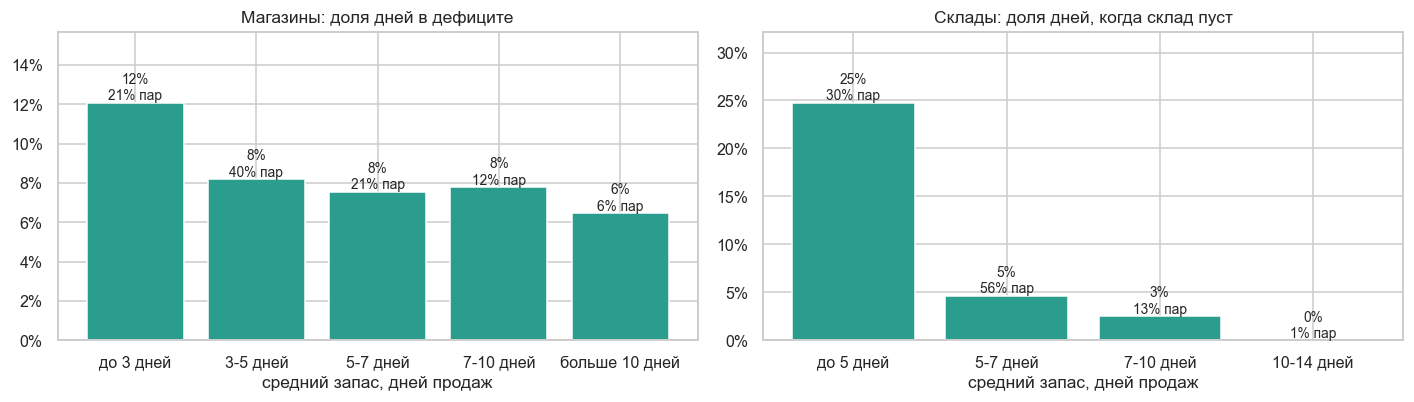

In [14]:
# График: доля дней дефицита по группам запаса - магазины и склады.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, t, title in [(axes[0], store_cover, 'Магазины: доля дней в дефиците'),
                     (axes[1], wh_cover, 'Склады: доля дней, когда склад пуст')]:
    ax.bar(t.index.astype(str), t.доля_дней_дефицита, color='#2a9d8f')
    for i, (v, n) in enumerate(zip(t.доля_дней_дефицита, t.доля_пар)):
        ax.text(i, v, f'{v:.0%}\n{n:.0%} пар', ha='center', va='bottom', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set(title=title, xlabel='средний запас, дней продаж')
    ax.set_ylim(0, t.доля_дней_дефицита.max() * 1.3)
fig.tight_layout(); plt.show()

Отдельно - дни, когда товар закончился в магазине за день: был ли в этот момент товар на складе. Если был,
магазин можно было пополнить больше или раньше.

In [15]:
# Доля потерь «закончился за день», когда на складе товар был (итог разбора - ошибка распределения).
z = dd[dd.Вид == 'закончился за день']
share = z.loc[z.Итог == 'ошибка распределения', 'Упущено_руб'].sum() / z.Упущено_руб.sum()
print(f'дни, когда товар закончился за день: {z.Упущено_руб.sum() / 1e6:.1f} млн ₽ потерь, '
      f'из них {share:.0%} - при товаре на складе')

дни, когда товар закончился за день: 143.3 млн ₽ потерь, из них 79% - при товаре на складе


## 6. Прогноз закупа после дефицита

Закупщик заказывает по средним отгрузкам склада за 3 недели. Пока склад пуст, отгрузок нет, прогноз падает -
и следующий заказ снова оказывается маленьким. Дефицит продлевает сам себя.

In [16]:
# Какая доля ошибок закупа случилась без заложенных сбоев закупщика - её даёт само правило прогноза.
b = dd[dd.Итог == 'ошибка закупа']
print(f'ошибка закупа: {b.Упущено_руб.sum() / 1e6:.1f} млн ₽, из них без заложенных сбоев закупщика - '
      f'{b.loc[b.Заложено == "без заложенной проблемы", "Упущено_руб"].sum() / b.Упущено_руб.sum():.0%}')

ошибка закупа: 75.2 млн ₽, из них без заложенных сбоев закупщика - 47%


## Сохранение результатов

Результаты записываются в схему `results` базы - из них собираются данные для страницы проекта на сайте.

In [17]:
# Записываем в базу разбор всех дней дефицита, сводные цифры и данные товара-примера - из них собирается страница сайта.
def save(frame: pd.DataFrame, table: str):
    con.execute('CREATE SCHEMA IF NOT EXISTS results')
    con.register('tmp_df', frame)
    con.execute(f'CREATE OR REPLACE TABLE results.{table} AS SELECT * FROM tmp_df')
    con.unregister('tmp_df')


save(dd[['Дата', 'Магазин', 'Склад', 'Номенклатура', 'Вид', 'Этап', 'Итог', 'Упущено_шт', 'Упущено_руб',
         'Упущено_истинно_руб', 'Заложено']].assign(Товар=lambda x: x.Номенклатура.map(sku_name)),
     'supply_deficits')

# сводные цифры для текста страницы
kinds = dd.Вид.value_counts()
summary = {
    'period_from': f'{dates[0]:%Y-%m-%d}', 'period_to': f'{dates[-1]:%Y-%m-%d}',
    'warehouses': len(warehouses), 'stores': len(stores), 'skus': len(products),
    'orders': len(orders), 'journal_rows': len(journal),
    'match_share': float((diff == 0).to_numpy().mean()), 'max_abs_diff': float(diff.to_numpy().max()),
    'days_active': n_active, 'days_empty': int(kinds.get('весь день без товара', 0)),
    'days_soldout': int(kinds.get('закончился за день', 0)),
    'sales_rub': float(sales_rub), 'lost_est': float(dd.Упущено_руб.sum()), 'lost_true': float(dd.Упущено_истинно_руб.sum()),
    'hit': float(hit), 'store_cover_days': float(store_days), 'wh_cover_days': float(wh_days),
    'soldout_lost': float(z.Упущено_руб.sum()), 'soldout_dist_share': float(share),
    'buy_err': float(b.Упущено_руб.sum()),
    'buy_err_systemic_share': float(b.loc[b.Заложено == 'без заложенной проблемы', 'Упущено_руб'].sum() / b.Упущено_руб.sum()),
    'example_sku': sku_name[example],
}
save(pd.DataFrame({'metric': list(summary), 'value': [str(v) for v in summary.values()]}), 'supply_summary')

# фактические запасы по группам
save(pd.concat([store_cover.reset_index().assign(уровень='Магазин'), wh_cover.reset_index().assign(уровень='Склад')])
     .assign(группа=lambda x: x.группа.astype(str)), 'supply_cover')

# сквозная картина по товару-примеру: остаток каждого склада и число его магазинов в дефиците по дням
rows = []
for w in warehouses:
    kids = [(s, example) for s in stores if store_wh[s] == w]
    rows.append(pd.DataFrame({'date': dates, 'warehouse': w, 'stock': stock_start[(w, example)].to_numpy(),
                              'deficit_stores': deficit.loc[:, kids].sum(axis=1).to_numpy()}))
save(pd.concat(rows, ignore_index=True), 'supply_example_daily')
save(orders[orders.Номенклатура == example].groupby('ДатаЗаказа', as_index=False)[['Заказано', 'Подтверждено']].sum()
     .rename(columns={'ДатаЗаказа': 'date', 'Заказано': 'ordered', 'Подтверждено': 'confirmed'}), 'supply_example_orders')
con.close()